In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

In [3]:
df_original = df.copy()

In [4]:
df = df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

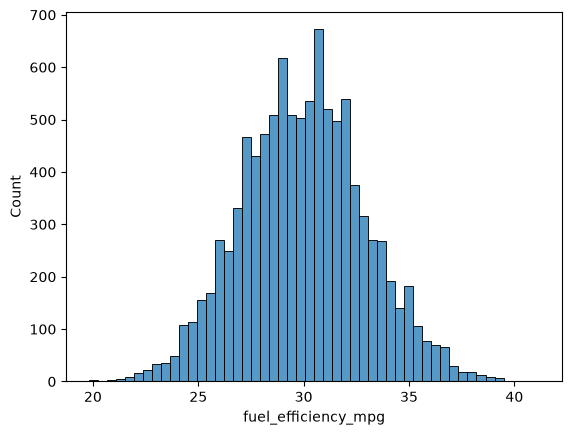

In [5]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [7]:
df.horsepower.median()

np.float64(254.0)

In [8]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [9]:
X_train = df_train[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']]
y_train = df_train.fuel_efficiency_mpg.values
X_val = df_val[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']]
y_val = df_val.fuel_efficiency_mpg.values
train_mean = X_train.horsepower.mean()

In [10]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [11]:
X_train_zeros = X_train.fillna(0).values
X_train_mean = X_train.fillna(train_mean).values
X_val_zeros = X_val.fillna(0).values
X_val_mean = X_val.fillna(train_mean).values

In [12]:
w0_z, w_z = train_linear_regression(X_train_zeros, y_train)
w0_m, w_m = train_linear_regression(X_train_mean, y_train)

In [13]:
y_z_pred = w0_z + X_val_zeros @ w_z
y_m_pred = w0_m + X_val_mean @ w_m

In [14]:
def rmse(y_pred, y):
    return math.sqrt(1.0/len(y_pred) * ((y_pred - y) ** 2).sum())

In [15]:
math.sqrt(1.0/len(y_z_pred) * ((y_z_pred - y_val) ** 2).sum())

2.205293194751098

In [16]:
math.sqrt(1.0/len(y_m_pred) * ((y_m_pred - y_val) ** 2).sum())

2.201817484568115

In [23]:
#Q4

r_list = [0, 0.01, 0.1, 1, 5, 10, 100]

rmse_list = []

def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

for r in r_list:
    w0, w = train_linear_regression_reg(X_train_zeros, y_train, r=r)
    y_pred = w0 + X_val_zeros.dot(w)
    rmse_list.append(round(rmse(y_pred, y_val),4))

rmse_list

[2.2053, 2.2058, 2.2241, 2.3492, 2.4094, 2.4195, 2.4292]

In [26]:
#Q5

seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_list_seed = []
for seed in seed_list:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    X_train = df_train[['engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year']].fillna(0).values
    y_train = df_train.fuel_efficiency_mpg.values
    X_val = df_val[['engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year']].fillna(0).values
    y_val = df_val.fuel_efficiency_mpg.values

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)
    rmse_list_seed.append(rmse(y_pred, y_val))

std=np.std(rmse_list_seed)
round(std,3)

np.float64(0.029)

In [29]:
#Q6

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

X_train = df_full_train[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']].fillna(0).values
y_train = df_full_train.fuel_efficiency_mpg.values
X_test = df_test[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']].fillna(0).values
y_test = df_test.fuel_efficiency_mpg.values

df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2320,246.0,4100,2014,32.5
1,2230,252.0,4250,1998,33.2
2,2700,276.0,4490,2008,32.4
3,2220,269.0,4060,2004,29.9
4,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
7995,2690,324.0,4510,2023,35.7
7996,1920,190.0,4000,1998,30.8
7997,1800,225.0,3980,1994,29.1
7998,1970,232.0,3560,2009,32.2


In [31]:
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)
y_pred = w0 + X_test.dot(w)
round(rmse(y_pred, y_test),3)

2.236